In [1]:
!pip install presidio-analyzer presidio-anonymizer spacy -q
!python -m spacy download en_core_web_lg -q

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import json
import re
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig
from datetime import datetime

In [3]:
analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

print("Presidio loaded successfully")
print(f"Supported entities: {analyzer.get_supported_entities()}")

Presidio loaded successfully
Supported entities: ['EMAIL_ADDRESS', 'IBAN_CODE', 'US_DRIVER_LICENSE', 'IP_ADDRESS', 'US_ITIN', 'US_BANK_NUMBER', 'LOCATION', 'UK_NHS', 'NRP', 'PHONE_NUMBER', 'CRYPTO', 'MAC_ADDRESS', 'CREDIT_CARD', 'US_PASSPORT', 'US_SSN', 'DATE_TIME', 'URL', 'PERSON', 'MEDICAL_LICENSE']


In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/Arjun-Barde/Clinical_Chat_Deidentification/main/counsel_chat.csv"
df = pd.read_csv(url)

print(f"Dataset loaded: {len(df)} rows")
print(f"Columns: {list(df.columns)}")
df[['questionText', 'answerText', 'topic']].head(3)

Dataset loaded: 2775 rows
Columns: ['questionID', 'questionTitle', 'questionText', 'questionLink', 'topic', 'therapistInfo', 'therapistURL', 'answerText', 'upvotes', 'views']


,questionText,answerText,topic
0,I have so many issues to address. I have a his...,It is very common for people to have multiple ...,depression
1,I have so many issues to address. I have a his...,"I've never heard of someone having ""too many i...",depression
2,I have so many issues to address. I have a his...,Absolutely not. I strongly recommending worki...,depression


In [7]:
def deidentify_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return text, []

    results = analyzer.analyze(text=text, language="en")
    anonymized = anonymizer.anonymize(
        text=text,
        analyzer_results=results,
        operators={
            "PERSON":       OperatorConfig("replace", {"new_value": "<PERSON>"}),
            "EMAIL_ADDRESS":OperatorConfig("replace", {"new_value": "<EMAIL>"}),
            "PHONE_NUMBER": OperatorConfig("replace", {"new_value": "<PHONE>"}),
            "LOCATION":     OperatorConfig("replace", {"new_value": "<LOCATION>"}),
            "DATE_TIME":    OperatorConfig("replace", {"new_value": "<DATE>"}),
            "US_SSN":       OperatorConfig("replace", {"new_value": "<SSN>"}),
            "URL":          OperatorConfig("replace", {"new_value": "<URL>"}),
        }
    )
    entities_found = [r.entity_type for r in results]
    return anonymized.text, entities_found

# Apply to a sample of 200 rows for speed
sample_df = df[['questionID', 'questionText', 'answerText', 'topic']].head(200).copy()

sample_df['clean_questionText'], sample_df['q_entities'] = zip(
    *sample_df['questionText'].apply(deidentify_text)
)
sample_df['clean_answerText'], sample_df['a_entities'] = zip(
    *sample_df['answerText'].apply(deidentify_text)
)

print(f"De-identification complete: {len(sample_df)} records processed")
print(f"\nExample:")
print(f"ORIGINAL: {sample_df['questionText'].iloc[5][:200]}")
print(f"CLEAN:    {sample_df['clean_questionText'].iloc[5][:200]}")

De-identification complete: 200 records processed

Example:
ORIGINAL: I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety
CLEAN:    I have so many issues to address. I have a history of sexual abuse, I’m a breast cancer survivor and I am a lifetime insomniac.    I have a long history of depression and I’m beginning to have anxiety


In [8]:
import matplotlib.pyplot as plt
from collections import Counter

In [9]:
all_entities = []
for entities in sample_df['q_entities']:
    all_entities.extend(entities)
for entities in sample_df['a_entities']:
    all_entities.extend(entities)

entity_counts = Counter(all_entities)

In [10]:
records_with_pii = sample_df[
    sample_df['q_entities'].apply(len) + sample_df['a_entities'].apply(len) > 0
].shape[0]

print("=" * 50)
print("DE-IDENTIFICATION QC REPORT")
print("=" * 50)
print(f"Total records processed : {len(sample_df)}")
print(f"Records with PII found  : {records_with_pii}")
print(f"Records clean (no PII)  : {len(sample_df) - records_with_pii}")
print(f"\nPII entities detected:")
for entity, count in entity_counts.most_common():
    print(f"  {entity:<25} {count}")

DE-IDENTIFICATION QC REPORT
Total records processed : 200
Records with PII found  : 161
Records clean (no PII)  : 39

PII entities detected:
  DATE_TIME                 214
  URL                       91
  PERSON                    22
  LOCATION                  8
  US_DRIVER_LICENSE         4
  PHONE_NUMBER              2
  NRP                       2
  US_BANK_NUMBER            1


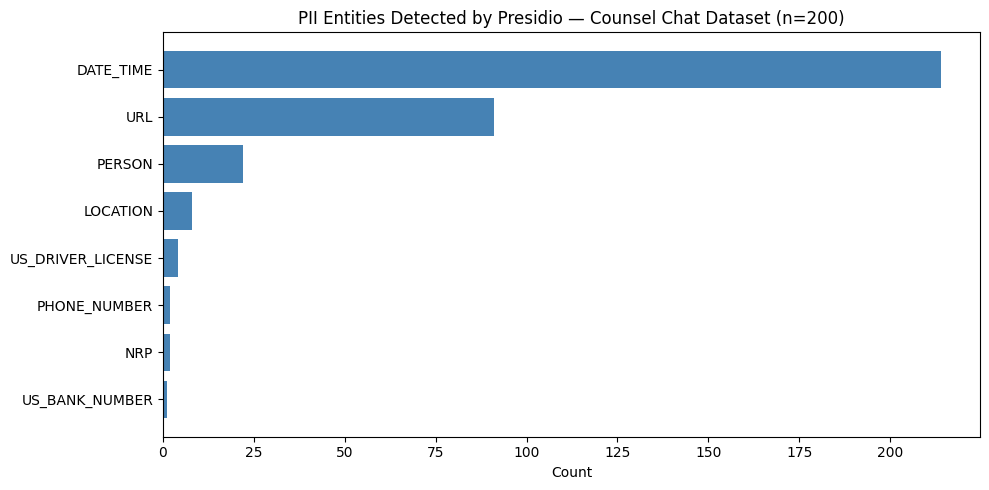


Chart saved as pii_report.png


In [11]:
if entity_counts:
    fig, ax = plt.subplots(figsize=(10, 5))
    labels, values = zip(*entity_counts.most_common())
    ax.barh(labels, values, color='steelblue')
    ax.set_xlabel("Count")
    ax.set_title("PII Entities Detected by Presidio — Counsel Chat Dataset (n=200)")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig("pii_report.png", dpi=150)
    plt.show()
    print("\nChart saved as pii_report.png")

In [16]:
output_df = sample_df[['questionID', 'topic', 'clean_questionText', 'clean_answerText']].copy()
output_df.columns = ['questionID', 'topic', 'questionText_clean', 'answerText_clean']
output_df.to_csv("counsel_chat_deidentified.csv", index=False)
print("CSV saved.")

CSV saved.


In [18]:
report = f"""# De-Identification QC Report
## Dataset: Counsel Chat (nbertagnolli/counsel-chat)
## Tool: Microsoft Presidio | Date: {datetime.now().strftime("%Y-%m-%d")}
"""

In [19]:

report_lines = [
    "# De-Identification QC Report",
    "## Dataset: Counsel Chat (nbertagnolli/counsel-chat)",
    "## Tool: Microsoft Presidio | Date: " + datetime.now().strftime("%Y-%m-%d"),
    "",
    "---",
    "",
    "## Summary",
    "",
    "| Metric | Value |",
    "|--------|-------|",
    f"| Total records processed | {len(sample_df)} |",
    f"| Records with PII detected | {records_with_pii} |",
    f"| Records with no PII | {len(sample_df) - records_with_pii} |",
    f"| PII detection rate | {records_with_pii/len(sample_df)*100:.1f}% |",
    "",
    "---",
    "",
    "## PII Entities Detected",
    "",
    "| Entity Type | Count |",
    "|-------------|-------|",
]

for entity, count in entity_counts.most_common():
    report_lines.append(f"| {entity} | {count} |")

report_lines += [
    "",
    "---",
    "",
    "## Notes",
    "- 200-record sample of the Counsel Chat dataset",
    "- Presidio NLP engine: spaCy en_core_web_lg",
    "- False positives possible for ambiguous patterns",
]

with open("QC_Report.md", "w") as f:
    f.write("\n".join(report_lines))

print("QC_Report.md saved.")

QC_Report.md saved.


In [20]:
from google.colab import files
files.download("counsel_chat_deidentified.csv")
files.download("QC_Report.md")
files.download("pii_report.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>